In [1]:
pip install numpy scipy matplotlib ipython scikit-learn pandas mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 8.7 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mglearn
import scipy as sp
import sklearn
import IPython

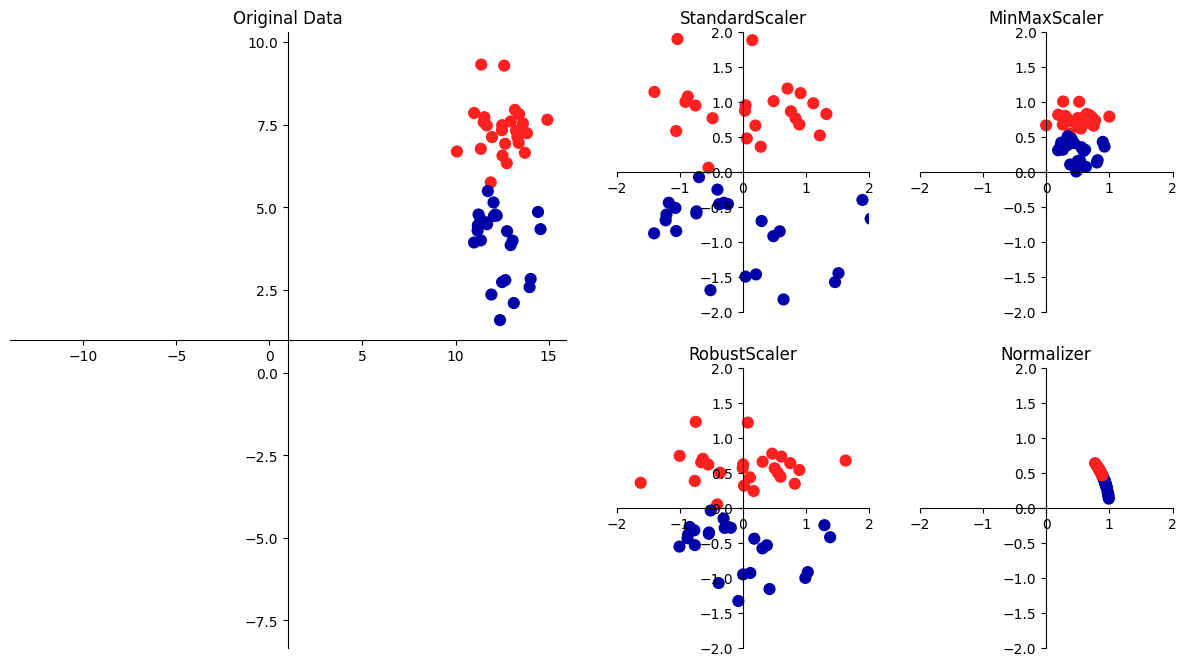

In [4]:
mglearn.plots.plot_scaling()

In [5]:
#Min-Max scaler
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC

cancer=load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer['data'], cancer['target'], random_state=0)
print("Train shape: ", X_train.shape)
print("Test shape: ", X_test.shape)
scaler=MinMaxScaler()
X_train_scaled=scaler.fit_transform(X_train)
print("Scaled train data shape: ", X_train_scaled.shape)
print("Per feature min before scaling:\n ", X_train.min(axis=0))
print("Per feature max before scaling:\n ", X_train.max(axis=0))
print("Per feature min after scaling:\n ", X_train_scaled.min(axis=0)) #This will scale data berween 0 and 1
print("Per feature max after scaling:\n ", X_train_scaled.max(axis=0))
#Now scale test data to apply SVM on scaled data
print("---------------------------------------------------------------")
print("Now scale test data to apply SVM on scaled data")
#We need to fit X_train while scaling X_test and then transform it using X_test
scaler.fit(X_train)
X_test_scaled=scaler.transform(X_test)
print("Per feature min before scaling:\n ", X_test.min(axis=0))
print("Per feature max before scaling:\n ", X_test.max(axis=0))
print("Per feature min after scaling:\n ", X_test_scaled.min(axis=0)) #This will scale data berween 0 and 1
print("Per feature max after scaling:\n ", X_test_scaled.max(axis=0))
print("---------------------------------------------------------------")
print("Now model trainig")
svm_no_scale=SVC(C=100).fit(X_train, y_train)
print("Training accuracy without scaling: ", svm_no_scale.score(X_train, y_train))
print("Test accuracy without scaling: ", svm_no_scale.score(X_test, y_test))
svm_scaled=SVC(C=100).fit(X_train_scaled, y_train)
print("Training accuracy after scaling: ", svm_scaled.score(X_train_scaled, y_train))
print("Test accuracy after scaling: ", svm_scaled.score(X_test_scaled, y_test))

Train shape:  (426, 30)
Test shape:  (143, 30)
Scaled train data shape:  (426, 30)
Per feature min before scaling:
  [6.981e+00 9.710e+00 4.379e+01 1.435e+02 5.263e-02 1.938e-02 0.000e+00
 0.000e+00 1.060e-01 4.996e-02 1.115e-01 3.628e-01 7.570e-01 7.228e+00
 1.713e-03 2.252e-03 0.000e+00 0.000e+00 7.882e-03 8.948e-04 7.930e+00
 1.202e+01 5.041e+01 1.852e+02 7.117e-02 2.729e-02 0.000e+00 0.000e+00
 1.565e-01 5.504e-02]
Per feature max before scaling:
  [2.811e+01 3.381e+01 1.885e+02 2.501e+03 1.447e-01 3.114e-01 4.268e-01
 2.012e-01 3.040e-01 9.744e-02 2.873e+00 4.885e+00 2.198e+01 5.422e+02
 2.333e-02 1.064e-01 3.960e-01 5.279e-02 6.146e-02 2.984e-02 3.604e+01
 4.954e+01 2.512e+02 4.254e+03 2.226e-01 1.058e+00 1.252e+00 2.903e-01
 6.638e-01 2.075e-01]
Per feature min after scaling:
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
Per feature max after scaling:
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1

## Principal Component Analysis (PCA)

Original shape:  (569, 30)
Reduced shape:  (569, 2)
PCA explained variance ratio:  [0.44272026 0.18971182]
Cumulative:  [0.44272026 0.63243208]
PCA component shape:  (2, 30)
PCA components:
  [[ 0.21890244  0.10372458  0.22753729  0.22099499  0.14258969  0.23928535
   0.25840048  0.26085376  0.13816696  0.06436335  0.20597878  0.01742803
   0.21132592  0.20286964  0.01453145  0.17039345  0.15358979  0.1834174
   0.04249842  0.10256832  0.22799663  0.10446933  0.23663968  0.22487053
   0.12795256  0.21009588  0.22876753  0.25088597  0.12290456  0.13178394]
 [-0.23385713 -0.05970609 -0.21518136 -0.23107671  0.18611302  0.15189161
   0.06016536 -0.0347675   0.19034877  0.36657547 -0.10555215  0.08997968
  -0.08945723 -0.15229263  0.20443045  0.2327159   0.19720728  0.13032156
   0.183848    0.28009203 -0.21986638 -0.0454673  -0.19987843 -0.21935186
   0.17230435  0.14359317  0.09796411 -0.00825724  0.14188335  0.27533947]]


Text(0, 0.5, 'Principal components')

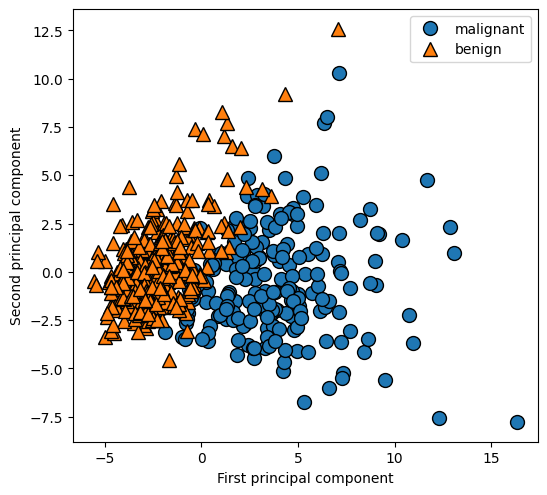

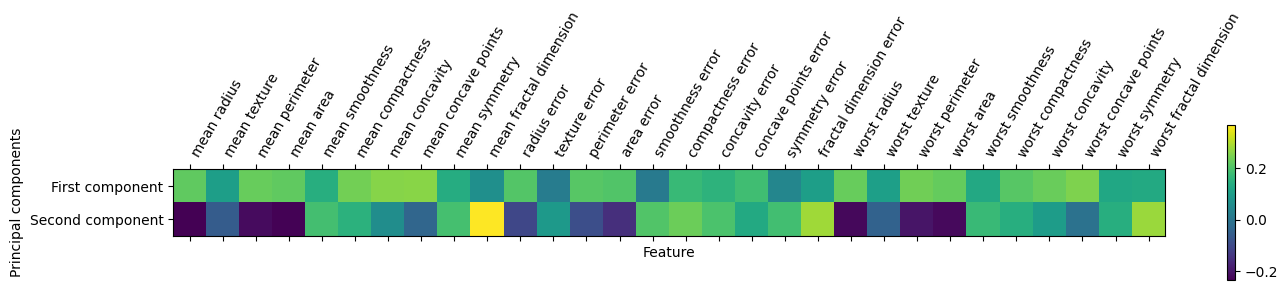

In [6]:
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

cancer=load_breast_cancer()
X, y= cancer.data, cancer.target

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X) #Scale features

pca=PCA(n_components=2) #Leaving it blank will fit all features, can use n_components=n where n can be the first n components of data
X_pca=pca.fit_transform(X_scaled)
print("Original shape: ", X_scaled.shape)
print("Reduced shape: ", X_pca.shape)
print("PCA explained variance ratio: ", pca.explained_variance_ratio_)
print("Cumulative: ", np.cumsum(pca.explained_variance_ratio_))

#plot first vs second feature now
plt.figure(figsize=(6,6))
mglearn.discrete_scatter(X_pca[:, 0], X_pca[:, 1], cancer.target)
plt.legend(cancer.target_names, loc="best")
plt.gca().set_aspect("equal")
plt.xlabel("First principal component")
plt.ylabel("Second principal component")

print("PCA component shape: ", pca.components_.shape)
print("PCA components:\n ", pca.components_)

# visualize the coefficients using a heat map
plt.matshow(pca.components_, cmap='viridis')
plt.yticks([0, 1], ["First component", "Second component"])
plt.colorbar()
plt.xticks(range(len(cancer.feature_names)),
cancer.feature_names, rotation=60, ha='left')
plt.xlabel("Feature")
plt.ylabel("Principal components")

In [4]:
#Feature extraction
from sklearn.datasets import fetch_lfw_people

people = fetch_lfw_people(min_faces_per_person=20,resize=0.7)
image_shape = people.images[0].shape
# fix, axes = plt.subplots(2, 5, figsize=(15, 8),
#             subplot_kw={'xticks': (), 'yticks': ()})
# for target, image, ax in zip(people.target, people.images, axes.ravel()):
#     ax.imshow(image)
#     ax.set_title(people.target_names[target]

print("people.images.shape: {}".format(people.images.shape)) #there are 3023 iamges, 87x65 pixels
print("Number of classes: ", len(people.target_names)) #there are 62 different people's images

#Count how often each image appears
counts=np.bincount(people.target)
for i, (count, name) in enumerate(zip(counts, people.target_names)):
    print("{0:25} {1:3}".format(name, count), end="  ")
    if (i+1)%3==0:
        print()
#Here the data is bit skewed as there are many images of person like George W. Bush, Colin Powell
#To make data less skewed, we will take atmost 50 images per person.
mask=np.zeros(people.target.shape, dtype=np.bool)
for target in np.unique(people.target):
    mask[np.where(people.target==target)[0][:50]] =1

X_people=people.data[mask]
y_people=people.target[mask]
X_people=X_people/255 #Scale the grayscale values to be between 0 and 1 instead of 0 and 255 for better numeric stability

#Common problem in face recognition task is having big training data. But there can be very different people in face databases,
#and very few images of the same person. That makes it hard for classifiers to train. A simple sol is to use one nearest neighbor.
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_people, y_people, stratify=y_people, random_state=0)
knn=KNeighborsClassifier(n_neighbors=1).fit(X_train, y_train)
print("\nTest score of 1-nn: ", knn.score(X_test, y_test))

#We obtain an accuracy of 21.5%, which is not actually that bad for a 62-class classification problem 
#(random guessing would give you around 1/62 = 1.5% accuracy)

#This is where PCA comes in (we enable whitening option of PCAwhich rescales PCs to have same scale). This is same as using Standardscaler after transformation.
from sklearn.decomposition import PCA
# mglearn.plots.plot_pca_whitening() #This plots whitened data
pca=PCA(n_components=100, whiten=True, random_state=0).fit(X_train)
X_train_pca=pca.transform(X_train)
X_test_pca=pca.transform(X_test)
print("X_train_pca shape: ", X_train_pca.shape)
print("X_test_pca shape: ", X_test_pca.shape)
#Training model on PCA data
knn_p=KNeighborsClassifier(n_neighbors=1).fit(X_train_pca, y_train)
print("\nTest accuracy after PCA: ", knn_p.score(X_test_pca, y_test))
#Here the accuracy improved from 21.5% to 29.6%


people.images.shape: (3023, 87, 65)
Number of classes:  62
Alejandro Toledo           39  Alvaro Uribe               35  Amelie Mauresmo            21  
Andre Agassi               36  Angelina Jolie             20  Ariel Sharon               77  
Arnold Schwarzenegger      42  Atal Bihari Vajpayee       24  Bill Clinton               29  
Carlos Menem               21  Colin Powell              236  David Beckham              31  
Donald Rumsfeld           121  George Robertson           22  George W Bush             530  
Gerhard Schroeder         109  Gloria Macapagal Arroyo    44  Gray Davis                 26  
Guillermo Coria            30  Hamid Karzai               22  Hans Blix                  39  
Hugo Chavez                71  Igor Ivanov                20  Jack Straw                 28  
Jacques Chirac             52  Jean Chretien              55  Jennifer Aniston           21  
Jennifer Capriati          42  Jennifer Lopez             21  Jeremy Greenstock          24  
J

### Non Negative MAtrix Factorization (NMF)

/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


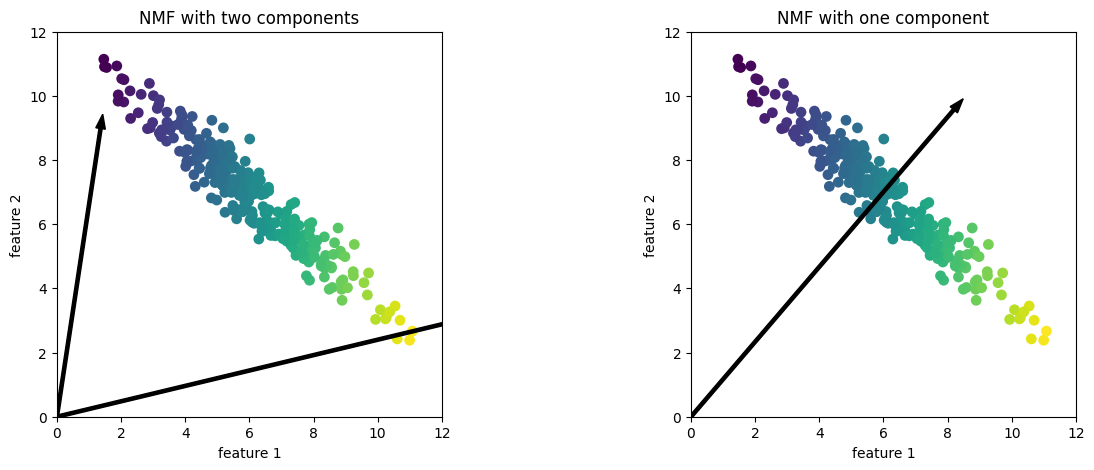

In [8]:
mglearn.plots.plot_nmf_illustration()

/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


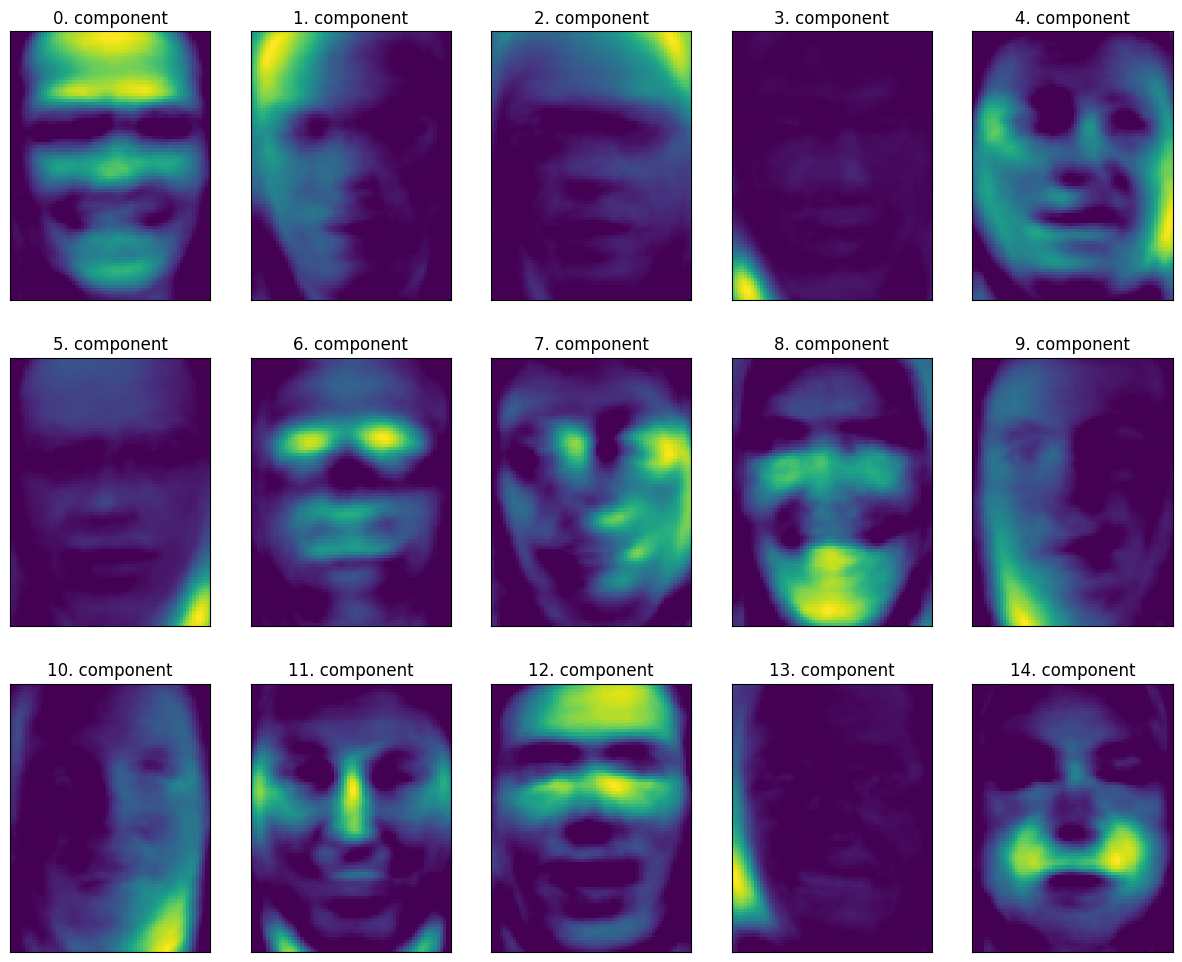

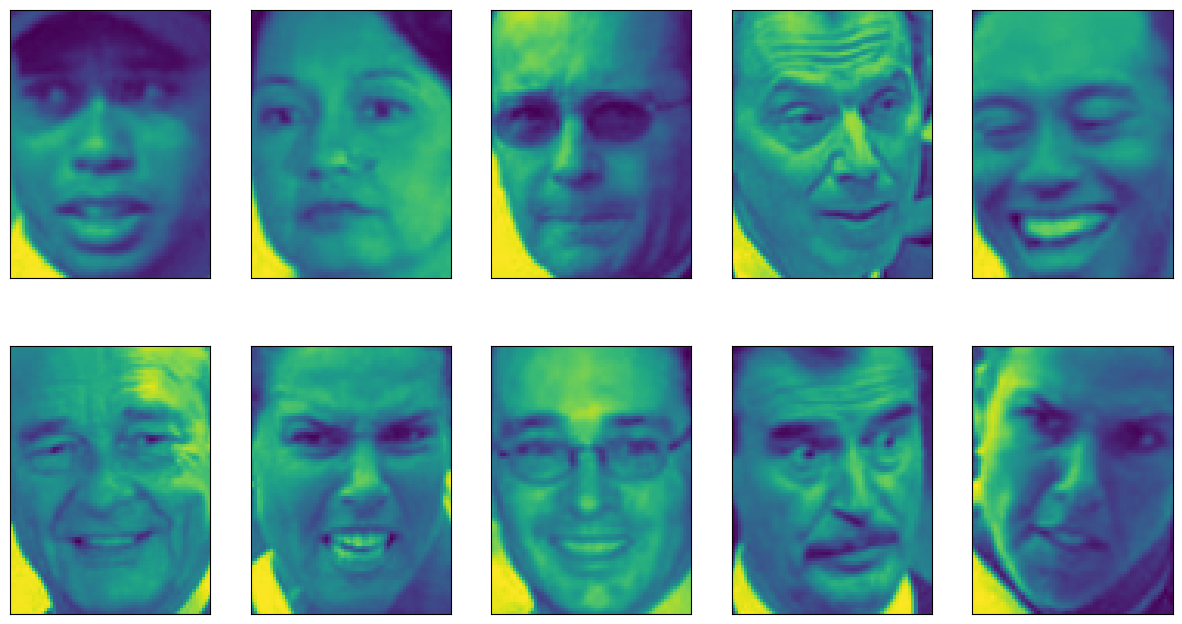

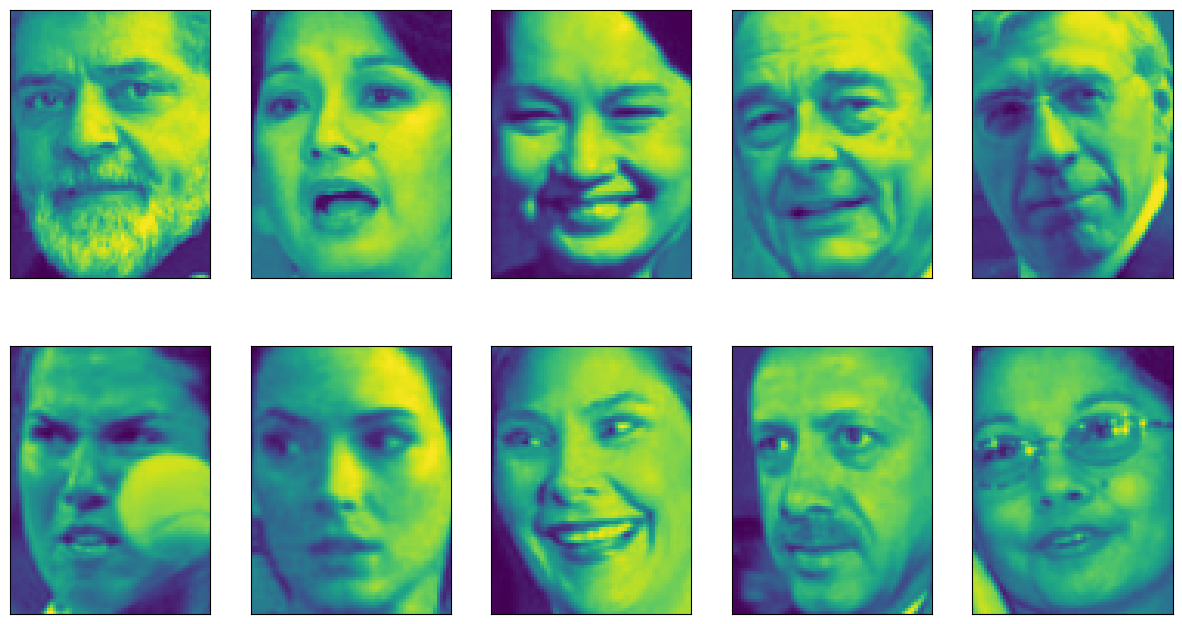

In [5]:
#NMF to face images
from sklearn.decomposition import NMF
nmf=NMF(n_components=15, random_state=0).fit(X_train)
X_train_nmf=nmf.transform(X_train)
X_test_nmf=nmf.transform(X_test)

fix, axes = plt.subplots(3, 5, figsize=(15, 12), subplot_kw={'xticks': (), 'yticks': ()})
for i, (component, ax) in enumerate(zip(nmf.components_, axes.ravel())):
    ax.imshow(component.reshape(image_shape))
    ax.set_title("{}. component".format(i))

compn = 3
# sort by 3rd component, plot first 10 images
inds = np.argsort(X_train_nmf[:, compn])[::-1]
fig, axes = plt.subplots(2, 5, figsize=(15, 8),subplot_kw={'xticks': (), 'yticks': ()})
for i, (ind, ax) in enumerate(zip(inds, axes.ravel())):
    ax.imshow(X_train[ind].reshape(image_shape))

compn = 7
# sort by 7th component, plot first 10 images
inds = np.argsort(X_train_nmf[:, compn])[::-1]
fig, axes = plt.subplots(2, 5, figsize=(15, 8),subplot_kw={'xticks': (), 'yticks': ()})
for i, (ind, ax) in enumerate(zip(inds, axes.ravel())):
    ax.imshow(X_train[ind].reshape(image_shape))

### Manifold Learning with t-SNE

Text(0.5, 1.0, 'With t-SNE')

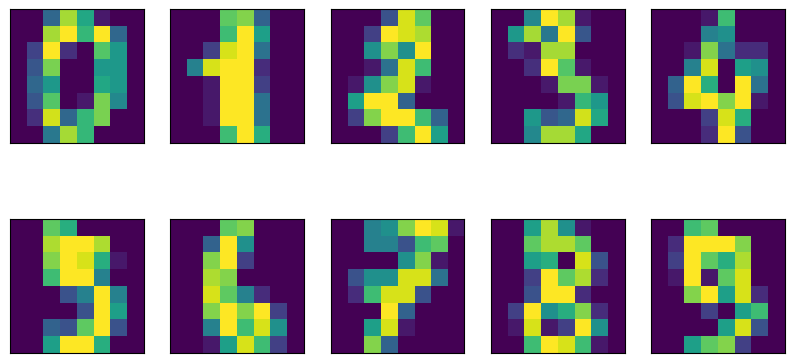

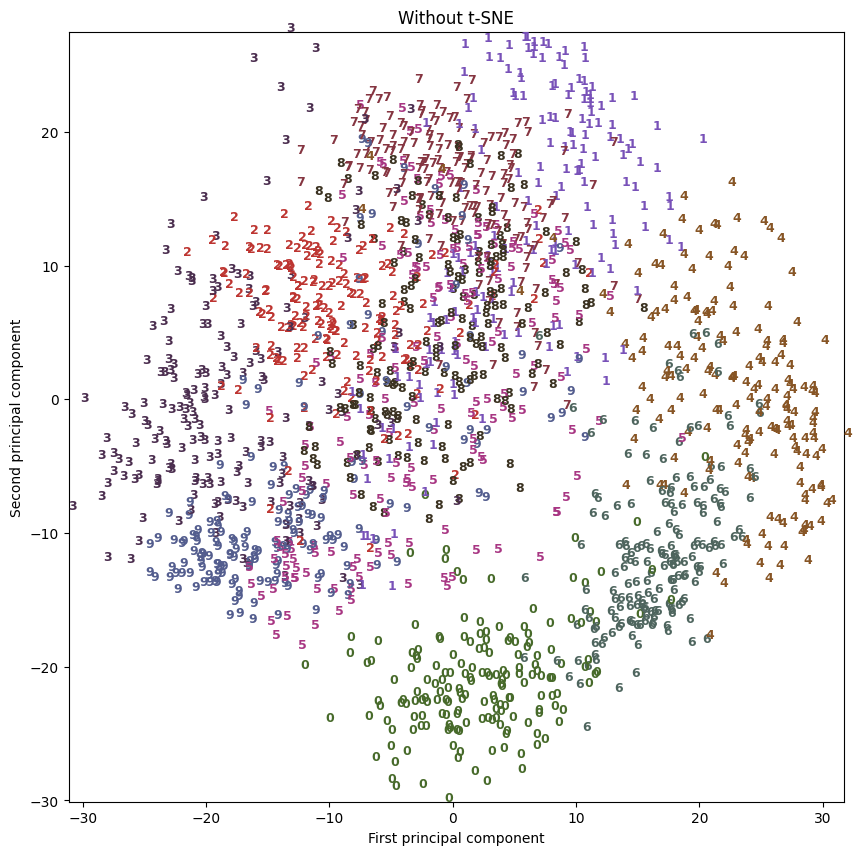

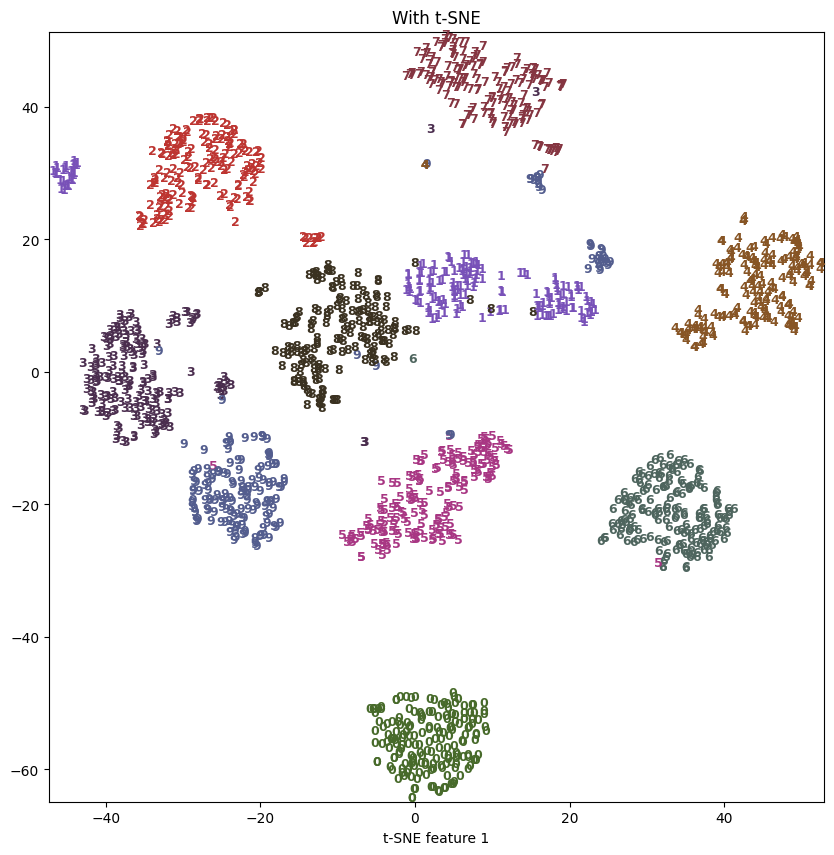

In [10]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
digits=load_digits()

fig, axes = plt.subplots(2, 5, figsize=(10, 5),subplot_kw={'xticks':(), 'yticks': ()})
for ax, img in zip(axes.ravel(), digits.images):
    ax.imshow(img)

#Now use PCA to visualize the data reduced to two dimensions.
pca=PCA(n_components=2).fit(digits.data)
digits_pca=pca.transform(digits.data)
colors = ["#476A2A", "#7851B8", "#BD3430", "#4A2D4E", "#875525", "#A83683", "#4E655E", "#853541", "#3A3120", "#535D8E"]
plt.figure(figsize=(10, 10))
plt.xlim(digits_pca[:, 0].min(), digits_pca[:, 0].max())
plt.ylim(digits_pca[:, 1].min(), digits_pca[:, 1].max())
for i in range(len(digits.data)):
# actually plot the digits as text instead of using scatter
    plt.text(digits_pca[i, 0], digits_pca[i, 1], str(digits.target[i]),color = colors[digits.target[i]],
             fontdict={'weight': 'bold', 'size': 9})
plt.xlabel("First principal component")
plt.ylabel("Second principal component")
plt.title("Without t-SNE")

#Now apply t-SNE to same dataset and compare results
from sklearn.manifold import TSNE
tsne=TSNE(random_state=42)
digits_tsne=tsne.fit_transform(digits.data)
plt.figure(figsize=(10, 10))
plt.xlim(digits_tsne[:, 0].min(), digits_tsne[:, 0].max() + 1)
plt.ylim(digits_tsne[:, 1].min(), digits_tsne[:, 1].max() + 1)
for i in range(len(digits.data)):
# actually plot the digits as text instead of using scatter
    plt.text(digits_tsne[i, 0], digits_tsne[i, 1], str(digits.target[i]),color = colors[digits.target[i]],
             fontdict={'weight': 'bold', 'size': 9})
plt.xlabel("t-SNE feature 0")
plt.xlabel("t-SNE feature 1")
plt.title("With t-SNE")

## Clustering

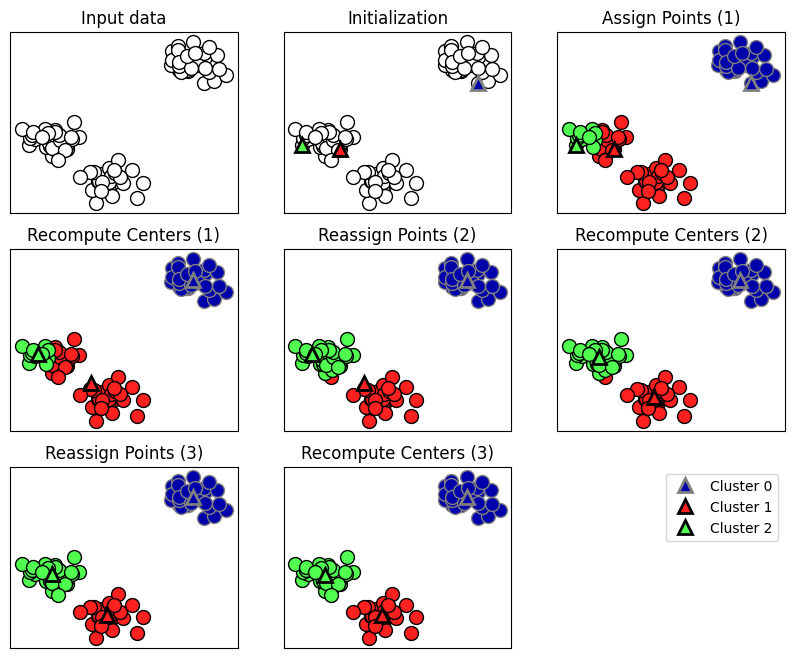

In [4]:
mglearn.plots.plot_kmeans_algorithm()

#### KMeans Clustering

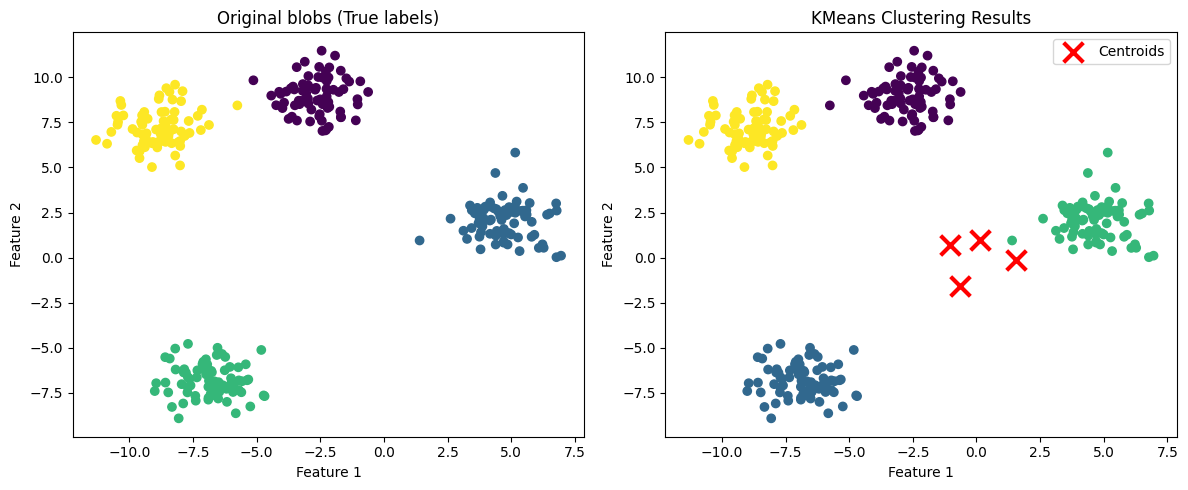

Cluster membership:
  [3 3 0 1 3 1 2 1 0 2 0 2 0 0 3 0 3 2 0 0 2 0 1 3 0 3 3 1 1 2 0 2 3 2 3 0 3
 1 3 1 2 0 3 1 0 0 3 2 3 2 1 3 1 0 1 2 3 2 2 0 3 2 2 0 1 1 1 1 1 0 1 1 3 2
 0 3 1 1 0 1 0 0 3 0 1 3 3 2 2 2 3 0 3 0 0 3 1 0 3 3 2 2 2 0 0 0 0 0 1 3 2
 0 0 0 0 2 3 1 3 1 1 1 0 3 1 3 3 0 3 1 2 0 0 0 0 2 2 3 0 1 0 2 1 0 2 2 2 2
 1 0 0 3 2 1 0 2 1 3 3 2 0 3 1 3 2 3 1 0 0 0 0 0 1 2 2 1 1 2 2 1 3 0 3 2 2
 3 1 0 2 2 1 1 1 3 2 1 1 2 2 3 0 0 1 2 0 1 1 3 1 0 0 1 1 2 3 1 3 3 0 3 3 1
 3 1 2 2 3 3 2 2 2 3 0 1 2 1 3 2 3 3 3 1 1 2 3 1 1 1 3 1 3 1 3 2 1 3 2 0 3
 0 2 0 3 0 1 2 1 2 2 0 0 1 2 2 3 3 1 0 0 2 2 2 2 1 3 2 1 2 2 1 0 1 2 0 3 0
 2 0 3 3]
Cluster assignments:  [76 75 75 74]
Inertia (within-cluster sum of squares):  17.466197609060583


In [10]:
#On synthetic data #KMeans
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

X, y_true = make_blobs(n_samples=300, n_features=2, centers=4, cluster_std=1.0, random_state=42)

scaler=StandardScaler()
X_scaled = scaler.fit_transform(X)

#Apply k means clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels=kmeans.fit_predict(X_scaled)

#Visualize results
fig, (ax1, ax2)= plt.subplots(1,2,figsize=(12,5))

#Original data with true labels
ax1.scatter(X[:,0], X[:,1], c=y_true, cmap="viridis")
ax1.set_title("Original blobs (True labels)")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")

#Kmeans results (discovered cluster)
ax2.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap="viridis")
ax2.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:,1], c='red', marker='x', s=200, linewidths=3, label='Centroids')
ax2.set_title("KMeans Clustering Results")
ax2.set_xlabel("Feature 1")
ax2.set_ylabel("Feature 2")
ax2.legend()

plt.tight_layout()
plt.show()

#print cluster info
print("Cluster membership:\n ", kmeans.labels_)
print("Cluster assignments: ", np.bincount(cluster_labels))
print("Inertia (within-cluster sum of squares): ", kmeans.inertia_)

Dataset shape: (1797, 64)
Number of classes: 10


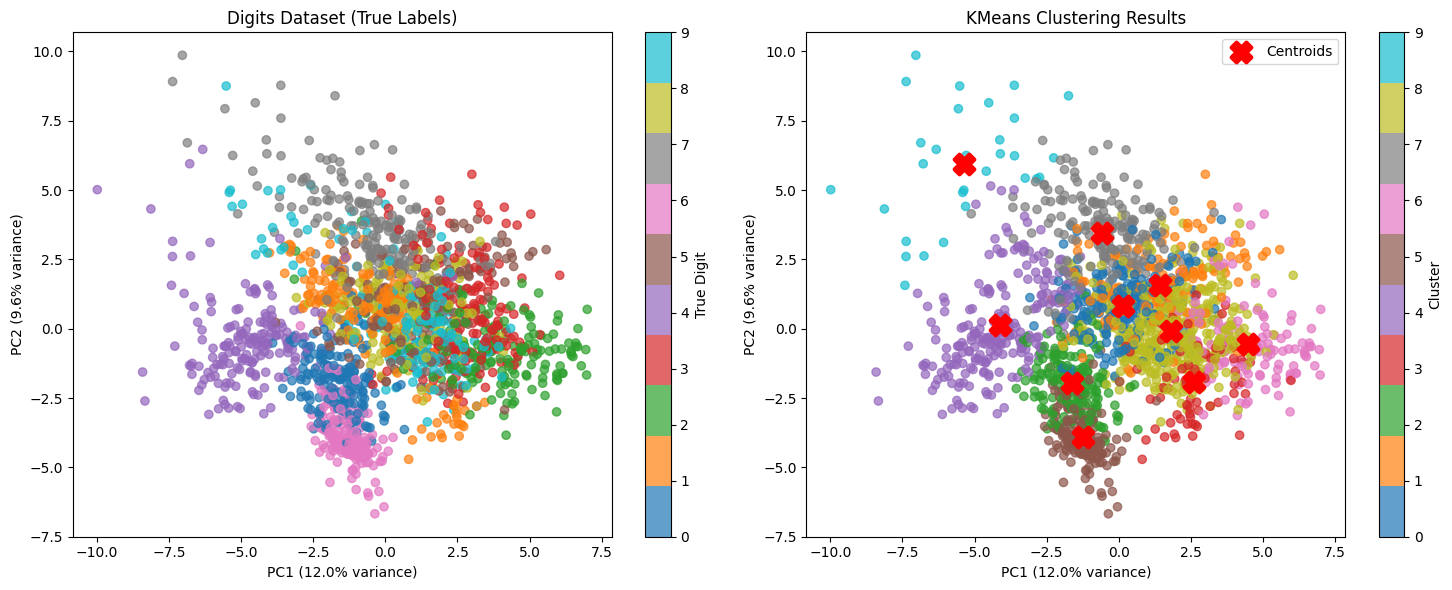

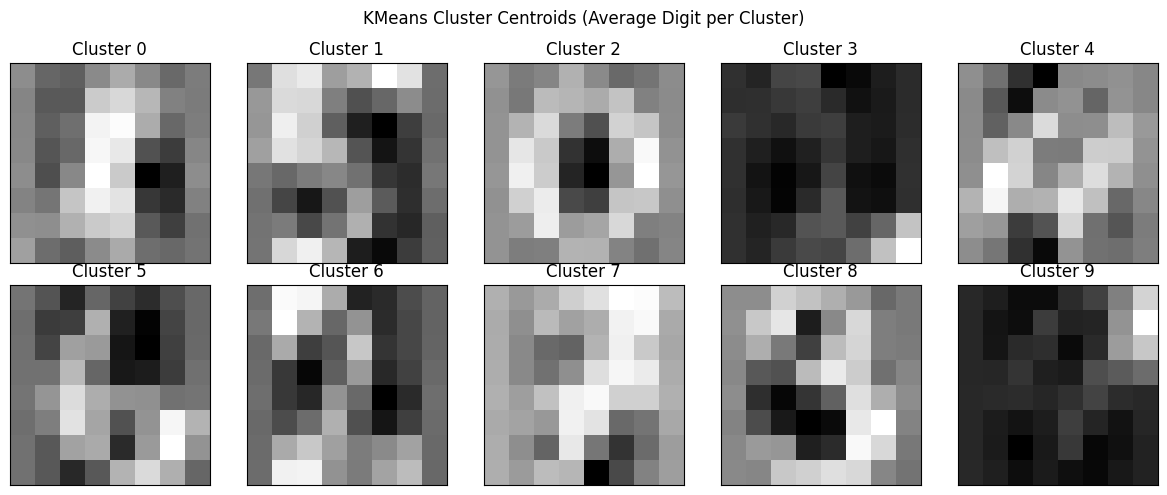

Cluster membership:
  [2 0 0 ... 0 8 8]
Cluster sizes: [245 156 177  71 232 179 127 183 397  30]
Inertia: 69813.56


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load digits dataset (1797 samples, 64 features = 8x8 images)
digits = load_digits()
X = digits.data  # 1797 x 64 pixel intensities
y_true = digits.target  # True digit labels (0-9) for reference only

print(f"Dataset shape: {X.shape}")
print(f"Number of classes: {len(np.unique(y_true))}")

# Scale features (critical for distance-based KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans (10 clusters for 10 digits)
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Reduce to 2D for visualization using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left: True labels in PCA space
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='tab10', alpha=0.7)
ax1.set_title('Digits Dataset (True Labels)')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.colorbar(scatter1, ax=ax1, label='True Digit')

# Right: KMeans clusters in PCA space
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', alpha=0.7)
ax2.scatter(pca.transform(kmeans.cluster_centers_)[:, 0], 
           pca.transform(kmeans.cluster_centers_)[:, 1], 
           c='red', marker='X', s=200, linewidth=3, label='Centroids')
ax2.set_title('KMeans Clustering Results')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax2.legend()
plt.colorbar(scatter2, ax=ax2, label='Cluster')

plt.tight_layout()
plt.show()

# Display some cluster centroids as images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
centers = kmeans.cluster_centers_
for i, ax in enumerate(axes.ravel()):
    # Reshape centroid back to 8x8 image
    img = centers[i].reshape(8, 8)
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Cluster {i}')
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle('KMeans Cluster Centroids (Average Digit per Cluster)')
plt.tight_layout()
plt.show()

# Print metrics
print("Cluster membership:\n ", kmeans.labels_)
print(f"Cluster sizes: {np.bincount(cluster_labels)}")
print(f"Inertia: {kmeans.inertia_:.2f}")


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


Text(0, 0.5, 'nmf')

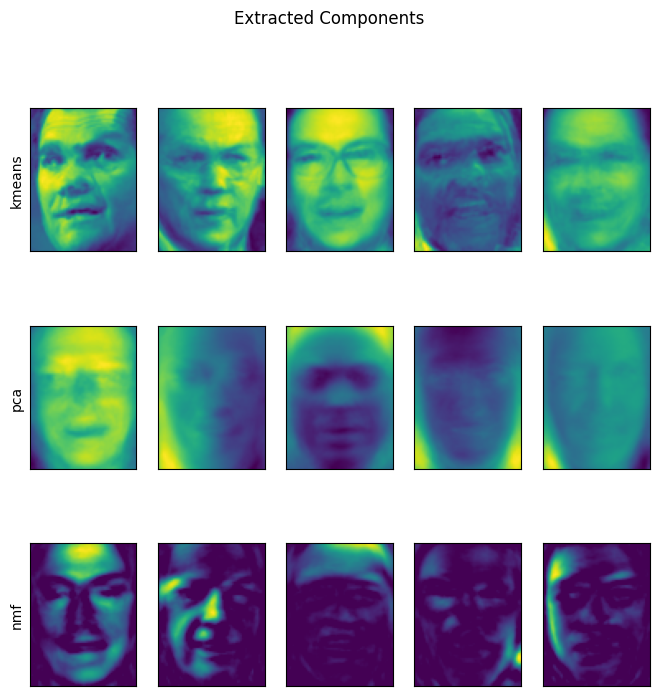

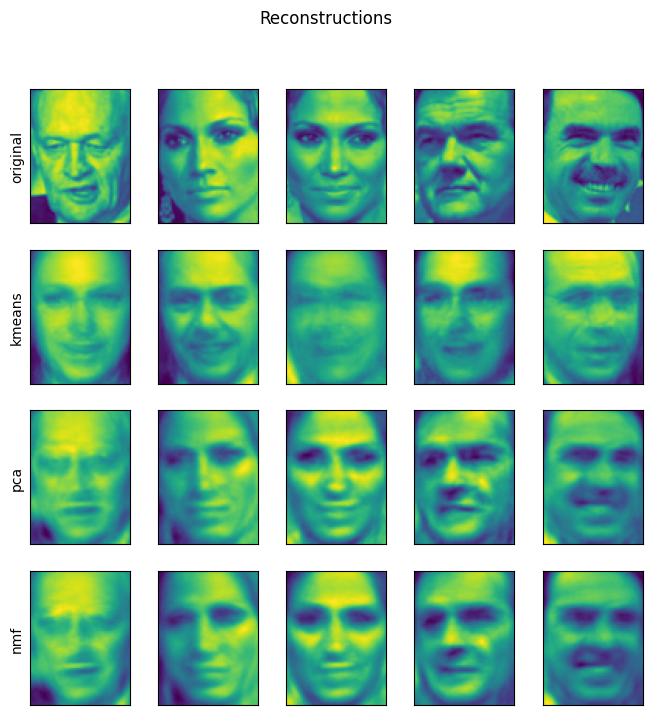

In [8]:
#Comparison between PCA, NMF and K-Means as decomposition
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA, NMF
from sklearn.cluster import KMeans
X_train, X_test, y_train, y_test = train_test_split(X_people, y_people, stratify=y_people, random_state=0)
nmf = NMF(n_components=100, random_state=0)
nmf.fit(X_train)
pca = PCA(n_components=100, random_state=0)
pca.fit(X_train)
kmeans = KMeans(n_clusters=100, random_state=0)
kmeans.fit(X_train)
X_reconstructed_pca = pca.inverse_transform(pca.transform(X_test))
X_reconstructed_kmeans = kmeans.cluster_centers_[kmeans.predict(X_test)]
X_reconstructed_nmf = np.dot(nmf.transform(X_test), nmf.components_)

fig, axes = plt.subplots(3, 5, figsize=(8, 8),subplot_kw={'xticks': (), 'yticks': ()})
fig.suptitle("Extracted Components")
for ax, comp_kmeans, comp_pca, comp_nmf in zip(axes.T, kmeans.cluster_centers_, pca.components_, nmf.components_):
    ax[0].imshow(comp_kmeans.reshape(image_shape))
    ax[1].imshow(comp_pca.reshape(image_shape), cmap='viridis')
    ax[2].imshow(comp_nmf.reshape(image_shape))
axes[0, 0].set_ylabel("kmeans")
axes[1, 0].set_ylabel("pca")
axes[2, 0].set_ylabel("nmf")

fig, axes = plt.subplots(4, 5, subplot_kw={'xticks': (), 'yticks': ()},figsize=(8, 8))
fig.suptitle("Reconstructions")
for ax, orig, rec_kmeans, rec_pca, rec_nmf in zip(axes.T, X_test, X_reconstructed_kmeans, X_reconstructed_pca,X_reconstructed_nmf):
    ax[0].imshow(orig.reshape(image_shape))
    ax[1].imshow(rec_kmeans.reshape(image_shape))
    ax[2].imshow(rec_pca.reshape(image_shape))
    ax[3].imshow(rec_nmf.reshape(image_shape))
axes[0, 0].set_ylabel("original")
axes[1, 0].set_ylabel("kmeans")
axes[2, 0].set_ylabel("pca")
axes[3, 0].set_ylabel("nmf")

Cluster memberships:
[8 4 6 3 1 1 5 2 8 4 9 2 1 4 7 5 0 2 0 7 1 2 0 4 9 6 1 1 6 0 8 9 2 6 8 1 2
 5 3 6 2 7 8 6 4 9 5 7 6 2 7 2 1 3 4 8 0 4 0 9 2 3 1 8 4 3 9 4 9 3 2 3 2 6
 2 3 6 8 0 2 1 9 2 1 6 9 5 9 2 1 0 5 1 7 1 1 4 2 3 6 4 1 9 5 3 6 3 7 4 0 7
 9 9 3 8 4 8 1 2 8 8 7 6 9 6 7 5 6 4 1 5 7 3 6 4 4 4 3 1 8 6 6 0 9 7 5 6 4
 0 6 2 4 8 0 2 9 4 2 0 0 6 4 0 4 2 1 0 2 4 2 0 3 3 7 6 2 1 7 7 0 4 3 1 4 1
 0 9 2 3 7 3 0 8 5 6 7 1 6 9 4]
Cluster bins:  [20 24 26 19 26 11 24 17 15 18]
Distance feature shape:  (200, 10)
Distance features:
  [[0.53664613 1.15017588 0.93237626 ... 1.48034956 0.002907   1.07736639]
 [1.74138152 0.60592307 1.00666225 ... 2.52921971 1.20779969 2.23716489]
 [0.75710543 1.93145038 0.91586549 ... 0.78321505 0.87573753 0.71838465]
 ...
 [0.9274342  1.73811046 0.57899268 ... 1.11471941 0.83358544 1.04125672]
 [0.3227627  1.97647071 1.47861069 ... 0.81425026 0.84551232 0.28446737]
 [1.63322944 0.47226506 1.02289983 ... 2.46626118 1.09767675 2.14812753]]


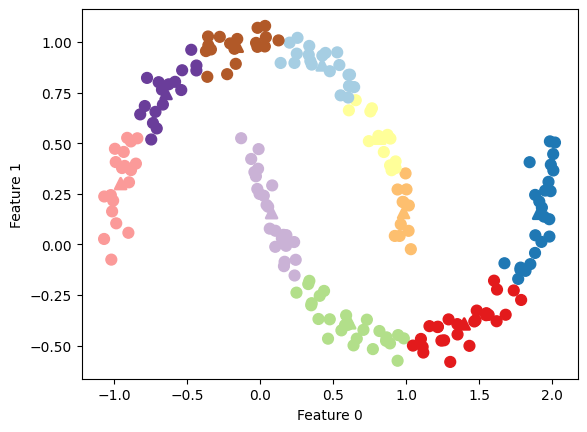

In [11]:
#Kmeans on two_moons data as it a complex data
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans

X, y=make_moons(n_samples=200, noise=0.05, random_state=0)
kmeans=KMeans(n_clusters=10, random_state=0).fit(X)
y_pred=kmeans.predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=60, cmap='Paired')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=60,
marker='^', c=range(kmeans.n_clusters), linewidth=2, cmap='Paired')
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
print("Cluster memberships:\n{}".format(y_pred))
print("Cluster bins: ", np.bincount(y_pred))

#Now using this 10-D representation, it would now be possible to separate the two half moon shapes using a linear-model.

#Now transforming the data to get more expressive representation of data using cluster centers.
distance_features=kmeans.transform(X)
print("Distance feature shape: ", distance_features.shape)
print("Distance features:\n ", distance_features)

#### Agglomerative Clustering

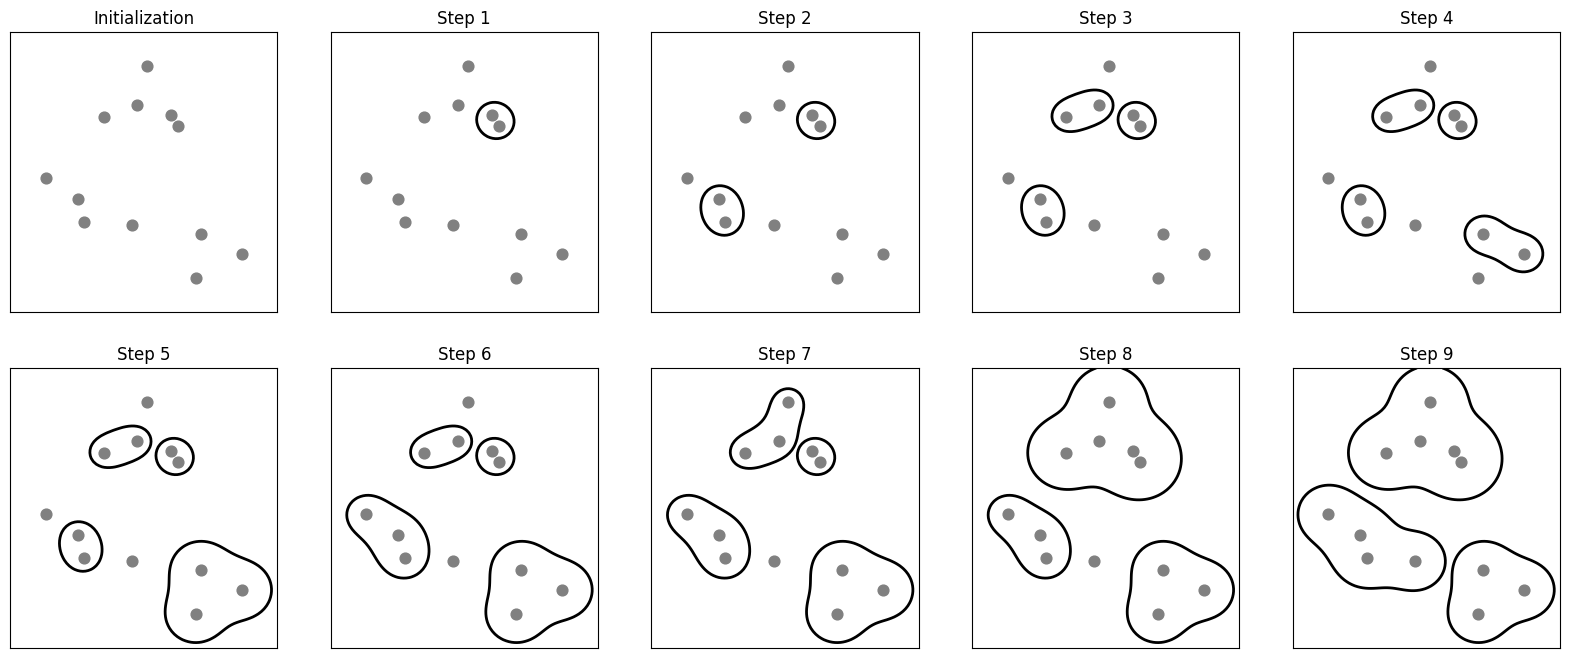

In [3]:
#Agglomerative clustering
mglearn.plots.plot_agglomerative_algorithm()


Text(0, 0.5, 'Feature 1')

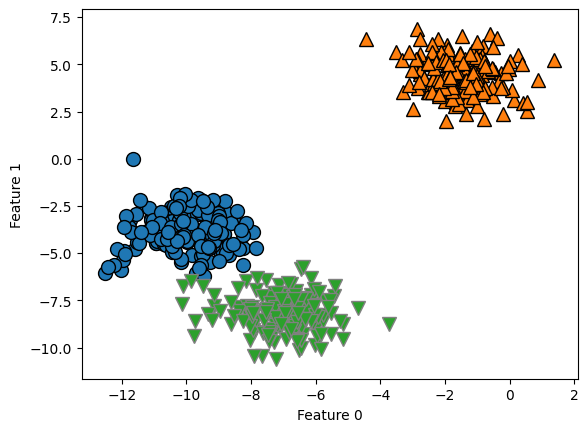

In [5]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs

X, y=make_blobs(n_samples=500, random_state=1)

agg=AgglomerativeClustering(n_clusters=3)
assignment=agg.fit_predict(X)

mglearn.discrete_scatter(X[:,0], X[:,1], assignment)
plt.xlabel('Feature 0')
plt.ylabel("Feature 1")

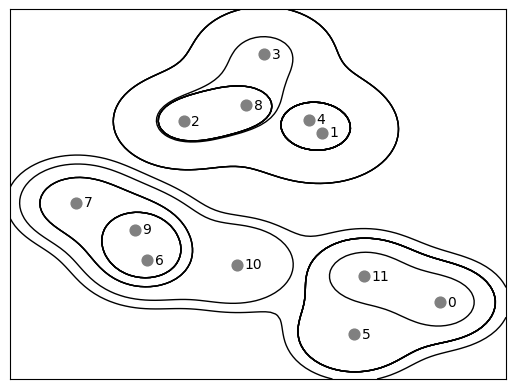

In [6]:
mglearn.plots.plot_agglomerative()


#### DBSCAN

Cluster membership:  [ 0  0  1 -1  1  2  0  1  0  1  1  1  1  2  0  1  2  1 -1  1  0  1  0  2
  1  1  2  2 -1  0  0  2  0  0  0  0  2  0  0  2  1  1  2  1  1  0 -1  1
  2 -1  2  1  1  1 -1  1  0  0  0  2 -1  2  2  0  2  0  1  0  0 -1  1  2
  1  0  1  0  0  1  1  2  0  2  1  2  2  2  2  2  3  1  2  0  0 -1  2  0
  3  1  3  2  2  0  2  2  2  0  0 -1  2  0  0  0  2  2  2  2  2  1  2 -1
  1  0  1  0  1  2  2  0  0  3  2  2  0  1  1  0  2  1 -1  2  0  0  0  2
  2  2 -1  0  1  1  1  2  2  1  2  1  1  0  0  2  0  2  2  2 -1  1  1 -1
  2  0  2  0  0 -1  0  1  0  1  0  1 -1  2  1  0  1  1  0  0  1  2 -1 -1
  1  1  2  1  0  1  2  0  2  1  0  0  0  0  1  1  0  0  0  1  1  0  0  2
  0  2  1  0  0  1  0  0  2  1  0  2  1  2  0  0  2 -1  0  1  2  1  1  2
 -1  1  1  0  1  2  1 -1  1  2  2  1  1  2  3  2  1  0  2  1 -1  2  2  2
  1  1  0  0  0  2  1  2  2  1  2  0  1  2 -1  2  0  1  2  1  2  2  1  0
  0  2  1  1 -1  0  2 -1  0  0 -1  0  0  0  0  0  1  0  1 -1  2  2  1  1
  1  2  2  1  0  2  2 -1  0 -1

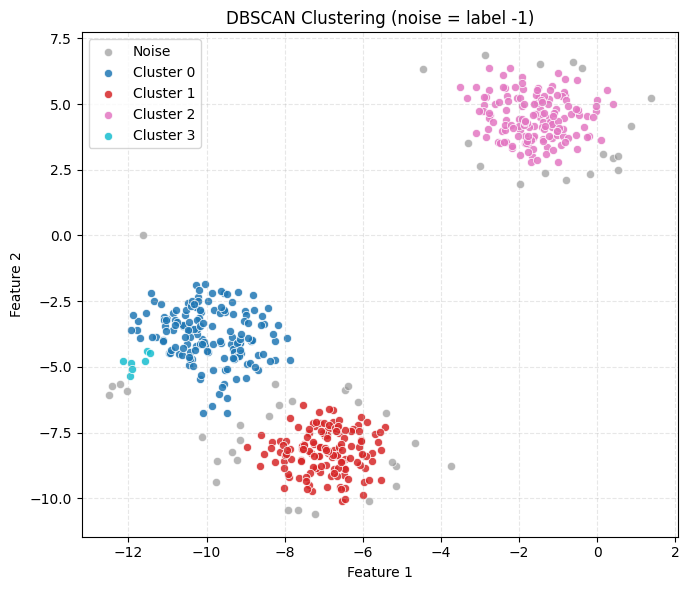

In [6]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs

X,y=make_blobs(n_samples=500, random_state=1)

dbscan=DBSCAN()
clusters=dbscan.fit_predict(X)
print("Cluster membership: ", clusters) #Label -1 means noise, other than are clusters


# --- Plotting ---
# Prepare colors: use a colormap for clusters; gray for noise
unique_labels = np.unique(clusters)
colors = plt.cm.tab10(np.linspace(0, 1, max(1, len(unique_labels) - (1 if -1 in unique_labels else 0))))

# Build a mapping from label -> color (exclude -1 for color map)
color_map = {}
color_idx = 0
for lbl in unique_labels:
    if lbl == -1:
        color_map[lbl] = (0.6, 0.6, 0.6, 0.8)  # gray for noise
    else:
        color_map[lbl] = colors[color_idx]
        color_idx += 1

plt.figure(figsize=(7, 6))

for lbl in unique_labels:
    mask = clusters == lbl
    plt.scatter(
        X[mask, 0],
        X[mask, 1],
        s=35,
        c=[color_map[lbl]],
        edgecolor="white",
        linewidth=0.6,
        label=("Noise" if lbl == -1 else f"Cluster {lbl}"),
        alpha=0.85 if lbl != -1 else 0.7,
        marker="o",
    )

plt.title("DBSCAN Clustering (noise = label -1)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(loc="best", frameon=True)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


min_samples: 2 eps: 1.000000  cluster: [-1  0  0 -1  0 -1  1  1  0  1 -1 -1]
min_samples: 2 eps: 1.500000  cluster: [0 1 1 1 1 0 2 2 1 2 2 0]
min_samples: 2 eps: 2.000000  cluster: [0 1 1 1 1 0 0 0 1 0 0 0]
min_samples: 2 eps: 3.000000  cluster: [0 0 0 0 0 0 0 0 0 0 0 0]
min_samples: 3 eps: 1.000000  cluster: [-1  0  0 -1  0 -1  1  1  0  1 -1 -1]
min_samples: 3 eps: 1.500000  cluster: [0 1 1 1 1 0 2 2 1 2 2 0]
min_samples: 3 eps: 2.000000  cluster: [0 1 1 1 1 0 0 0 1 0 0 0]
min_samples: 3 eps: 3.000000  cluster: [0 0 0 0 0 0 0 0 0 0 0 0]
min_samples: 5 eps: 1.000000  cluster: [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
min_samples: 5 eps: 1.500000  cluster: [-1  0  0  0  0 -1 -1 -1  0 -1 -1 -1]
min_samples: 5 eps: 2.000000  cluster: [-1  0  0  0  0 -1 -1 -1  0 -1 -1 -1]
min_samples: 5 eps: 3.000000  cluster: [0 0 0 0 0 0 0 0 0 0 0 0]


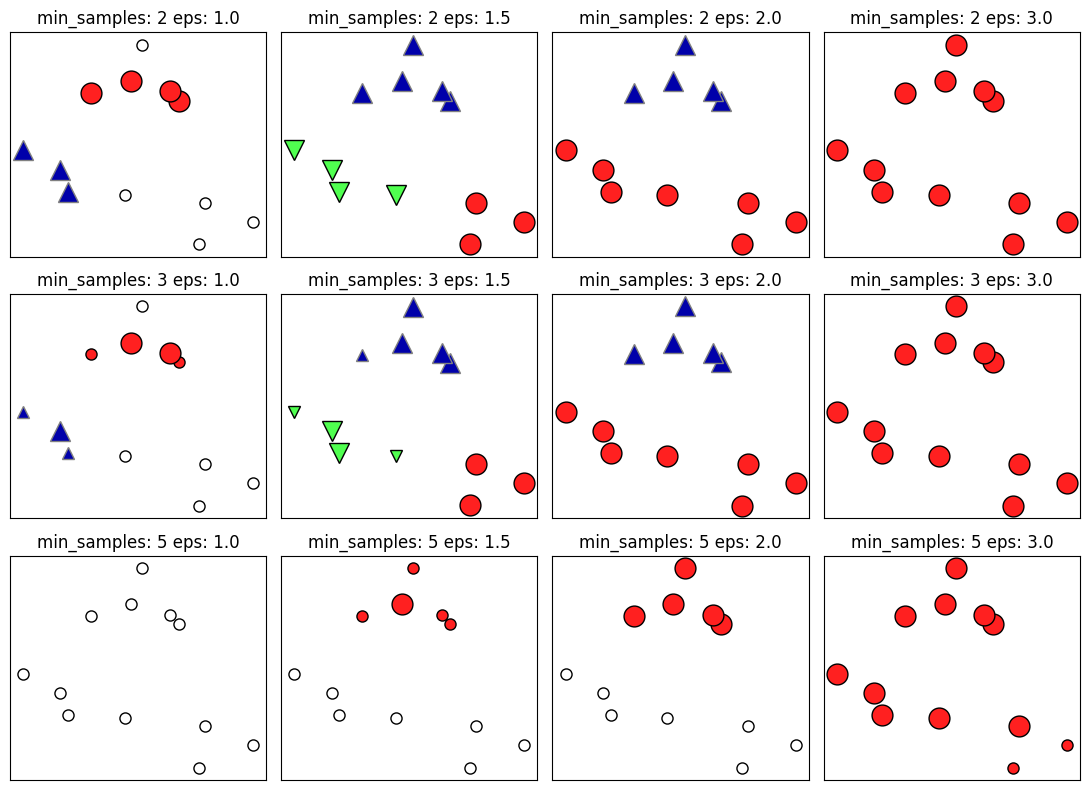

In [5]:
mglearn.plots.plot_dbscan()

Text(0, 0.5, 'Feature 1')

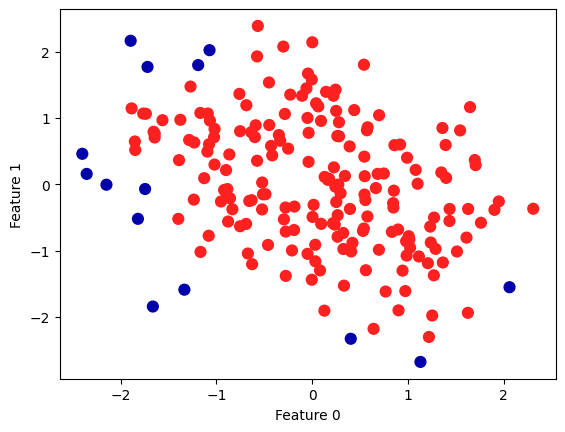

In [7]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

X,y=make_moons(n_samples=200, noise=0.5, random_state=0)
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

dbs=DBSCAN()
clusters=dbs.fit_predict(X_scaled)

#plot
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters, cmap=mglearn.cm2, s=60)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

### Clustering algos compariosn with ground truth

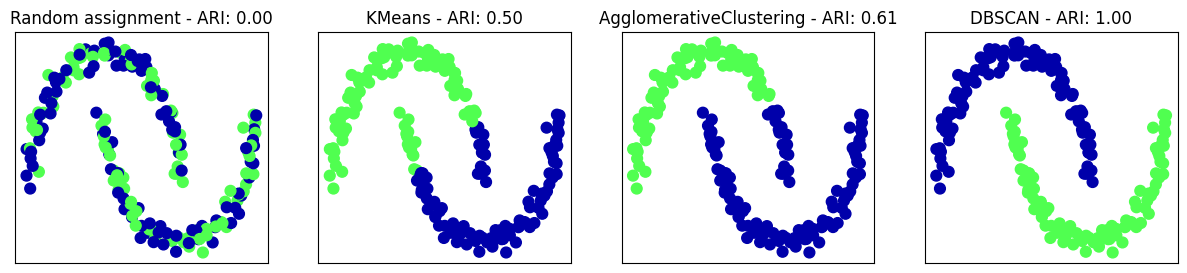

In [10]:
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

X,y=make_moons(n_samples=200, noise=0.05, random_state=0)

scaler=StandardScaler()
scaler.fit(X)
X_scaled=scaler.transform(X)

fig, axes = plt.subplots(1, 4, figsize=(15, 3),subplot_kw={'xticks': (), 'yticks': ()})
# make a list of algorithms to use
algorithms = [KMeans(n_clusters=2), AgglomerativeClustering(n_clusters=2),DBSCAN()]
# create a random cluster assignment for reference
random_state = np.random.RandomState(seed=0)
random_clusters = random_state.randint(low=0, high=2, size=len(X))
# plot random assignment
axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=random_clusters,cmap=mglearn.cm3, s=60)
axes[0].set_title("Random assignment - ARI: {:.2f}".format(adjusted_rand_score(y, random_clusters)))
for ax, algorithm in zip(axes[1:], algorithms):
    # plot the cluster assignments and cluster centers
    clusters = algorithm.fit_predict(X_scaled)
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters,cmap=mglearn.cm3, s=60)
    ax.set_title("{} - ARI: {:.2f}".format(algorithm.__class__.__name__,adjusted_rand_score(y, clusters)))


### Clustering algorithm comparisons without ground truth

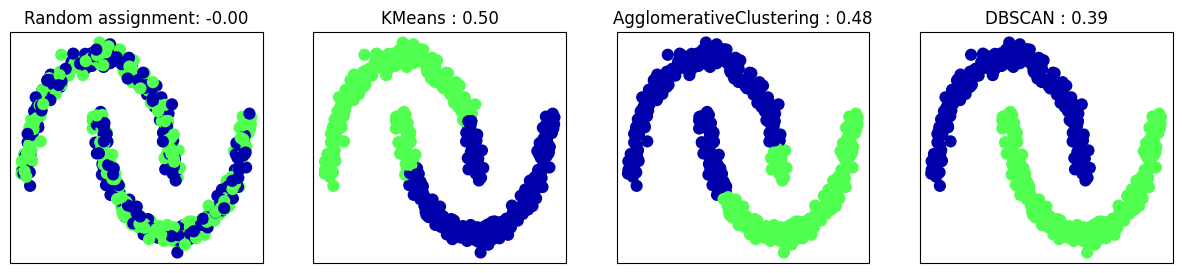

In [5]:
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.cluster import silhouette_score

X,y=make_moons(n_samples=500, noise=0.05, random_state=0)
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

fig, axes = plt.subplots(1, 4, figsize=(15, 3),subplot_kw={'xticks': (), 'yticks': ()})

# create a random cluster assignment for reference
random_state = np.random.RandomState(seed=0)
random_clusters = random_state.randint(low=0, high=2, size=len(X))
# plot random assignment
axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=random_clusters,cmap=mglearn.cm3, s=60)
axes[0].set_title("Random assignment: {:.2f}".format(silhouette_score(X_scaled, random_clusters)))
algorithms = [KMeans(n_clusters=2), AgglomerativeClustering(n_clusters=2),DBSCAN()]

for ax, algorithm in zip(axes[1:], algorithms):
    clusters = algorithm.fit_predict(X_scaled)
    # plot the cluster assignments and cluster centers
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap=mglearn.cm3,s=60)
    ax.set_title("{} : {:.2f}".format(algorithm.__class__.__name__,silhouette_score(X_scaled, clusters)))